In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
from torchvision import datasets
import torchvision.transforms as transforms

transform = transforms.ToTensor()
dataset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
dataset_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True,  num_workers=4)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.6MB/s]


Extracting /root/.pytorch/F_MNIST_data/FashionMNIST/raw/train-images-idx3-ubyte.gz to /root/.pytorch/F_MNIST_data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]


Extracting /root/.pytorch/F_MNIST_data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to /root/.pytorch/F_MNIST_data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.72MB/s]


Extracting /root/.pytorch/F_MNIST_data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to /root/.pytorch/F_MNIST_data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 14.1MB/s]

Extracting /root/.pytorch/F_MNIST_data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to /root/.pytorch/F_MNIST_data/FashionMNIST/raw



In [3]:
import torch.nn as nn
import torch.nn.functional as F

class Discriminator(nn.Module):

    def __init__(self, input_size, hidden_dim, output_size):
        super(Discriminator, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        
        self.fc6 = nn.Linear(hidden_dim, output_size)
        
        self.dropout = nn.Dropout(0.3)
        
        
    def forward(self, x):

        x = x.view(-1, 28*28)

        x = F.leaky_relu(self.fc1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc4(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc5(x), 0.2)
        x = self.dropout(x)

        out = self.fc6(x)

        return out

In [4]:
class Generator(nn.Module):

    def __init__(self, input_size, hidden_dim, output_size):
        super(Generator, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, hidden_dim)
        
        self.fc6 = nn.Linear(hidden_dim, output_size)
        
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2) 
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc4(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc5(x), 0.2)
        x = self.dropout(x)
        
        out = F.tanh(self.fc6(x))

        return out

In [5]:
input_size = 784
d_output_size = 1
d_hidden_size = 256
z_size = 64
g_output_size = 784
g_hidden_size = 256

D = Discriminator(input_size, d_hidden_size, d_output_size)
G = Generator(z_size, g_hidden_size, g_output_size)

In [6]:
def real_loss(D_out, smooth=False):
    batch_size = D_out.size(0)
    if smooth:
        labels = torch.ones(batch_size)*0.9
    else:
        labels = torch.ones(batch_size)
        
    criterion = nn.BCEWithLogitsLoss()
    loss = criterion(D_out.squeeze(), labels)
    return loss

def fake_loss(D_out):
    batch_size = D_out.size(0)
    labels = torch.zeros(batch_size)
    criterion = nn.BCEWithLogitsLoss()
    loss = criterion(D_out.squeeze(), labels)
    return loss

In [7]:
import torch.optim as optim

d_optimizer = optim.RAdam(D.parameters(), lr=0.0002, weight_decay=0.00001, decoupled_weight_decay=True, foreach=True)
g_optimizer = optim.RAdam(G.parameters(), lr=0.0002, weight_decay=0.00001, decoupled_weight_decay=True, foreach=True)

In [8]:
num_epochs = 100

samples = []
losses = []

print_every = 600

sample_size=16
fixed_z = np.random.uniform(-1, 1, size=(sample_size, z_size))
fixed_z = torch.from_numpy(fixed_z).float()

D.train()
G.train()
for epoch in range(num_epochs):
    
    for batch_i, (real_images, _) in enumerate(dataset_loader):
                
        batch_size = real_images.size(0)
        
        real_images = real_images*2 - 1 
        
        d_optimizer.zero_grad()

        D_real = D(real_images)
        d_real_loss = real_loss(D_real, smooth=True)
        
        with torch.no_grad():
            z = np.random.uniform(-1, 1, size=(batch_size, z_size))
            z = torch.from_numpy(z).float()
            fake_images = G(z)
             
        D_fake = D(fake_images)
        d_fake_loss = fake_loss(D_fake)
        
        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()
        
        g_optimizer.zero_grad()
        
        z = np.random.uniform(-1, 1, size=(batch_size, z_size))
        z = torch.from_numpy(z).float()
        fake_images = G(z)
        
        D_fake = D(fake_images)
        g_loss = real_loss(D_fake) 
        
        g_loss.backward()
        g_optimizer.step()

        if batch_i % print_every == 0:
            print('Epoch [{:5d}/{:5d}] | d_loss: {:6.4f} | g_loss: {:6.4f}'.format(
                    epoch+1, num_epochs, d_loss.item(), g_loss.item()))

    losses.append((d_loss.item(), g_loss.item()))
    
    G.eval()
    samples_z = G(fixed_z)
    samples.append(samples_z)
    G.train()

Epoch [    1/  100] | d_loss: 1.3866 | g_loss: 0.7099
Epoch [    1/  100] | d_loss: 0.4564 | g_loss: 3.7591
Epoch [    2/  100] | d_loss: 0.4783 | g_loss: 4.2626
Epoch [    2/  100] | d_loss: 0.4258 | g_loss: 5.6845
Epoch [    3/  100] | d_loss: 0.6101 | g_loss: 5.6295
Epoch [    3/  100] | d_loss: 0.5517 | g_loss: 4.6413
Epoch [    4/  100] | d_loss: 0.5211 | g_loss: 4.2887
Epoch [    4/  100] | d_loss: 0.7295 | g_loss: 3.3053
Epoch [    5/  100] | d_loss: 0.6162 | g_loss: 3.2621
Epoch [    5/  100] | d_loss: 0.7786 | g_loss: 3.0957
Epoch [    6/  100] | d_loss: 0.6860 | g_loss: 3.1707
Epoch [    6/  100] | d_loss: 0.9053 | g_loss: 2.7035
Epoch [    7/  100] | d_loss: 0.8596 | g_loss: 2.0988
Epoch [    7/  100] | d_loss: 0.7118 | g_loss: 2.1773
Epoch [    8/  100] | d_loss: 0.9756 | g_loss: 2.7317
Epoch [    8/  100] | d_loss: 0.7887 | g_loss: 2.3671
Epoch [    9/  100] | d_loss: 0.7894 | g_loss: 2.3824
Epoch [    9/  100] | d_loss: 0.9588 | g_loss: 2.1237
Epoch [   10/  100] | d_loss

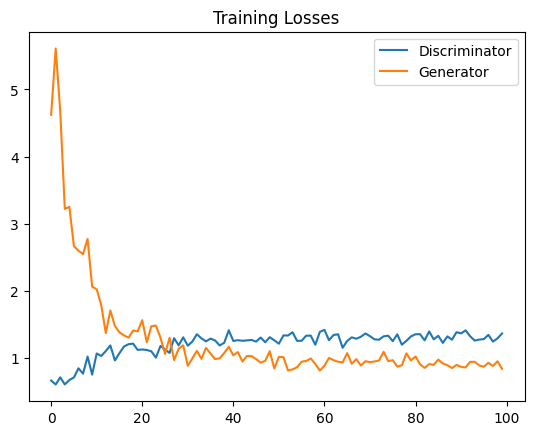

In [9]:
fig, ax = plt.subplots()
losses = np.array(losses)
plt.plot(losses.T[0], label='Discriminator')
plt.plot(losses.T[1], label='Generator')
plt.title("Training Losses")
plt.legend()

In [12]:
def view_samples(epoch, samples):
    fig, axes = plt.subplots(figsize=(7,5), nrows=5, ncols=5, sharey=True, sharex=True)
    for ax, img in zip(axes.flatten(), samples[epoch]):
        img = img.detach()
        ax.xaxis.set_visible(False)
        ax.yaxis.set_visible(False)
        im = ax.imshow(img.reshape((28,28)), cmap='Greys_r')

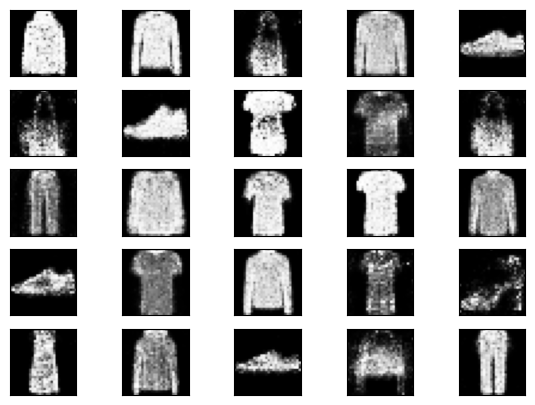

In [13]:
sample_size=25
rand_z = np.random.uniform(-1, 1, size=(sample_size, z_size))
rand_z = torch.from_numpy(rand_z).float()

G.eval() 
rand_images = G(rand_z)

view_samples(0, [rand_images])